## **0. Necessary Imports**

In [1]:
import os
import torch
import nltk
import torchvision
import torchaudio
import matplotlib.pyplot as plt
import random
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

## **1. Data Loading Process**

In [5]:
!kaggle datasets download -d adityajn105/flickr8k
!mkdir DATA
!unzip flickr8k.zip -d DATA

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
 49%|███████████████████▏                   | 521M/1.04G [00:00<00:00, 5.42GB/s]
100%|██████████████████████████████████████| 1.04G/1.04G [00:00<00:00, 5.64GB/s]
Archive:  flickr8k.zip
  inflating: DATA/Images/1000268201_693b08cb0e.jpg  
  inflating: DATA/Images/1001773457_577c3a7d70.jpg  
  inflating: DATA/Images/1002674143_1b742ab4b8.jpg  
  inflating: DATA/Images/1003163366_44323f5815.jpg  
  inflating: DATA/Images/1007129816_e794419615.jpg  
  inflating: DATA/Images/1007320043_627395c3d8.jpg  
  inflating: DATA/Images/1009434119_febe49276a.jpg  
  inflating: DATA/Images/1012212859_01547e3f17.jpg  
  inflating: DATA/Images/1015118661_980735411b.jpg  
  inflating: DATA/Images/1015584366_dfcec3c85a.jpg  
  inflating: DATA/Images/101654506_8eb26cfb60.jpg  
  inflating: DATA/Images/101669240_b2d3e7f17b.jpg  
  inflating: DATA/Images/1016887272_03199f49c4.jpg  
  inflating: DATA/Images/1019077836_6fc9b1

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("DATA/captions.txt")

unique_images = df['image'].unique()
print(f"Total unique images: {len(unique_images)}")

train_imgs, temp_imgs = train_test_split(unique_images, test_size=0.2, random_state=69)
val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=69)

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df = df[df['image'].isin(val_imgs)].reset_index(drop=True)
test_df = df[df['image'].isin(test_imgs)].reset_index(drop=True)

train_df.to_csv("DATA/train.csv", index=False)
val_df.to_csv("DATA/val.csv", index=False)
test_df.to_csv("DATA/test.csv", index=False)

print("-" * 30)
print(f"Training data:   {len(train_df)} captions ({len(train_imgs)} images)")
print(f"Validation data: {len(val_df)} captions ({len(val_imgs)} images)")
print(f"Test data:       {len(test_df)} captions ({len(test_imgs)} images)")

Total unique images: 8091
------------------------------
Training data:   32360 captions (6472 images)
Validation data: 4045 captions (809 images)
Test data:       4050 captions (810 images)


## **2. Defining Augmentations**

In [2]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

## **3. Creating Datasets and Dataloaders**

In [3]:
import spacy
from collections import Counter

spacy_eng = spacy.load("en_core_web_sm")

class Vocabulary:
    def __init__(self, freq_threshold=5):
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_eng(text):
        return [tok.text.lower() for tok in spacy_eng.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                frequencies[word] += 1

        for word, count in frequencies.items():
            if count >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<unk>"]
            for token in tokenized_text
        ]

In [4]:
class Flickr8kDataset(Dataset):
    def __init__(self, root_dir, df, transform=None, vocab=None):
        self.root_dir = root_dir
        self.df = df
        self.transform = transform
        self.vocab = vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.df.iloc[index]["caption"]
        img_id = self.df.iloc[index]["image"]

        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")
        img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<sos>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<eos>"])

        return img, torch.tensor(numericalized_caption)

In [5]:
from torch.nn.utils.rnn import pad_sequence

class Paddingtron:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)

        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)

        return imgs, targets

In [8]:
train_df = pd.read_csv("DATA/train.csv")
val_df = pd.read_csv("DATA/val.csv")
test_df = pd.read_csv("DATA/test.csv")

vocab = Vocabulary(5)
vocab.build_vocabulary(train_df["caption"].tolist())

train_dataset = Flickr8kDataset("DATA/Images", train_df, train_transforms, vocab)
val_dataset = Flickr8kDataset("DATA/Images", val_df, test_transforms, vocab)
test_dataset = Flickr8kDataset("DATA/Images", test_df, test_transforms, vocab)

paddingtron = Paddingtron(vocab.stoi["<pad>"])
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size, shuffle=True, collate_fn=paddingtron)
val_loader = DataLoader(val_dataset, batch_size, shuffle=True, collate_fn=paddingtron)
test_loader = DataLoader(test_dataset, batch_size, shuffle=False, collate_fn=paddingtron)

## **4.1 Visualizing Training Data**

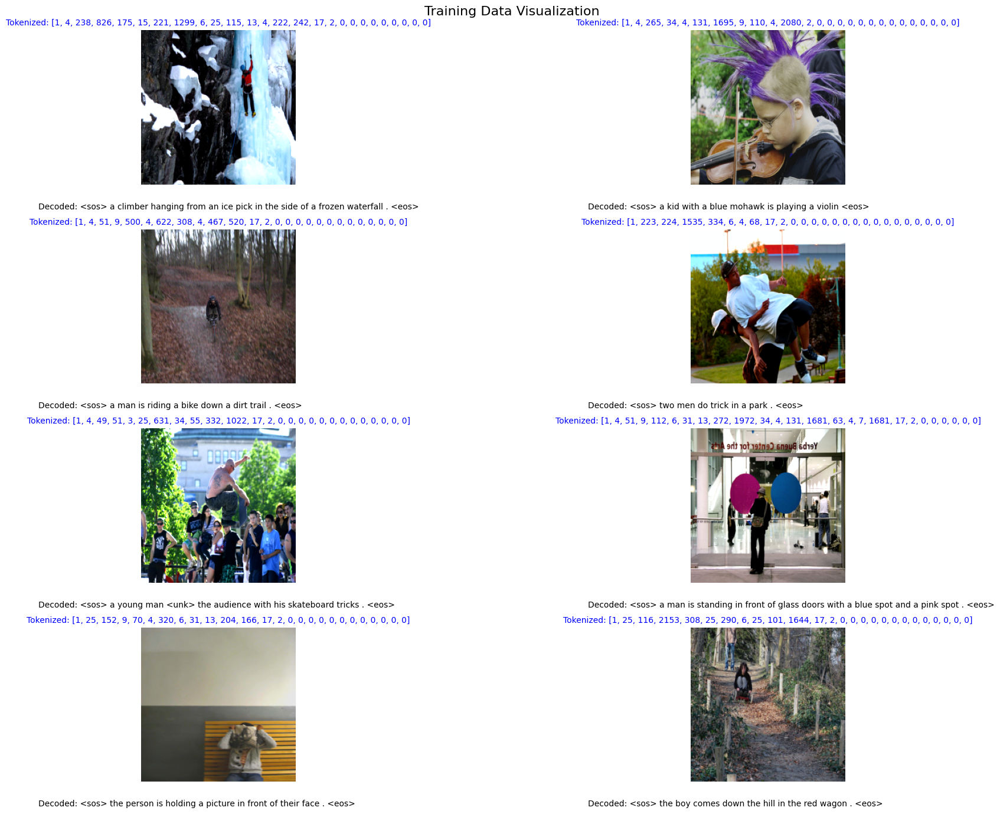

In [9]:
import numpy as np

def imshow(img, mean, std):
    img = img.numpy().transpose((1, 2, 0))
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.axis("off")


images, captions = next(iter(train_loader))
fig = plt.figure(figsize=(20, 14))

num_images = 8
cols = 2
rows = num_images // cols

for i in range(num_images):
    ax = fig.add_subplot(rows, cols, i+1)

    imshow(images[i], mean, std)

    current_caption_indices = captions[i].tolist()

    caption_words = [vocab.itos[idx] for idx in current_caption_indices if idx != vocab.stoi["<pad>"]]
    decoded_caption = " ".join(caption_words)

    ax.set_title(f"Tokenized: {current_caption_indices}", fontsize=10, color="blue")
    ax.text(-150, 250, f"Decoded: {decoded_caption}", fontsize=10, wrap=True, verticalalignment='top')


plt.suptitle("Training Data Visualization", fontsize=16)
plt.tight_layout()
plt.show()

## **4.2 Creating the Image Captioning Model**

In [10]:
import torch.nn as nn
import torchvision.models as models

class Encoder(nn.Module):
    def __init__(self, encoded_image_size=14):
        super(Encoder, self).__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)

        for p in self.resnet.parameters():
            p.requires_grad = True

        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))

    def forward(self, images):
        out = self.resnet(images)
        out = self.adaptive_pool(out)

        out = out.permute(0, 2, 3, 1)
        out = out.view(out.size(0), -1, out.size(3))

        return out

In [11]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()

        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_features, decoder_hidden):
        att1 = self.encoder_att(encoder_features)
        att2 = self.decoder_att(decoder_hidden)
        energy = self.full_att(self.relu(att1 + att2.unsqueeze(1)))

        alpha = self.softmax(energy)
        attention_weighted_encoding = (encoder_features * alpha).sum(dim=1)

        return attention_weighted_encoding, alpha.squeeze(2)

In [12]:
class Decoder(nn.Module):
    def __init__(self, embed_size, vocab_size, attention_dim, encoder_dim, decoder_dim, drop_prob=0.3):
        super(Decoder, self).__init__()

        self.vocab_size = vocab_size
        self.attention_dim = attention_dim
        self.decoder_dim = decoder_dim

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)

        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)

        self.lstm_cell = nn.LSTMCell(embed_size + encoder_dim, decoder_dim)

        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.fc = nn.Linear(decoder_dim, vocab_size)

        self.dropout = nn.Dropout(drop_prob)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)

        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)

        return h, c

    def forward(self, encoder_features, captions):
        batch_size = encoder_features.size(0)
        vocab_size = self.vocab_size
        num_pixels = encoder_features.size(1)

        embeddings = self.embedding(captions)

        h, c = self.init_hidden_state(encoder_features)

        seq_length = len(captions[0]) - 1

        predictions = torch.zeros(batch_size, seq_length, vocab_size).to(encoder_features.device)
        alphas = torch.zeros(batch_size, seq_length, num_pixels).to(encoder_features.device)

        for t in range(seq_length):
            context, alpha = self.attention(encoder_features, h)

            gate = torch.sigmoid(self.f_beta(h))
            gated_context = gate * context

            lstm_input = torch.cat((embeddings[:, t, :], gated_context), dim=1)

            h, c = self.lstm_cell(lstm_input, (h, c))

            output = self.fc(self.dropout(h))

            predictions[:, t, :] = output
            alphas[:, t, :] = alpha

        return predictions, alphas

In [ ]:
from torch.nn import functional as F

class EncoderDecoder(nn.Module):
    def __init__(self, embed_size, vocab_size, attention_dim, encoder_dim, decoder_dim):
        super(EncoderDecoder, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder(
            embed_size,
            vocab_size,
            attention_dim,
            encoder_dim,
            decoder_dim
        )

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs, alphas = self.decoder(features, captions)

        return outputs, alphas

    def generate(self, image_tensor, vocab, beam_width=3, max_len=20, device='cpu'):
        self.eval()
        
        if beam_width == 1:
            with torch.no_grad():
                encoder_features = self.encoder(image_tensor.to(device))
                h, c = self.decoder.init_hidden_state(encoder_features)
                
                start_token = vocab.stoi["<sos>"]
                current_word_idx = torch.tensor([[start_token]]).to(device)
                
                decoded_words = []
                attention_weights = [] 

                for t in range(max_len):
                    embeddings = self.decoder.embedding(current_word_idx).squeeze(1)
                    context, alpha = self.decoder.attention(encoder_features, h)
                    
                    attention_weights.append(alpha.view(14, 14).cpu().numpy())
                    
                    gate = torch.sigmoid(self.decoder.f_beta(h))
                    gated_context = gate * context
                    lstm_input = torch.cat((embeddings, gated_context), dim=1)
                    h, c = self.decoder.lstm_cell(lstm_input, (h, c))
                    
                    output = self.decoder.fc(h)
                    predicted_idx = output.argmax(dim=1)
                    predicted_word = vocab.itos[predicted_idx.item()]
                    
                    if predicted_word == "<eos>":
                        break
                        
                    decoded_words.append(predicted_word)
                    current_word_idx = predicted_idx.unsqueeze(0)

                
                return decoded_words, attention_weights

        else:
            k = beam_width
            with torch.no_grad():
                encoder_out = self.encoder(image_tensor.to(device))
            
            encoder_out = encoder_out.expand(k, -1, -1)
            h, c = self.decoder.init_hidden_state(encoder_out)
            
            start_token = vocab.stoi["<sos>"]
            current_word_idx = torch.LongTensor([[start_token]] * k).to(device)
            top_k_scores = torch.zeros(k, 1).to(device)
            
            if k > 1: top_k_scores[1:] = float('-inf')

            seqs = [[start_token] for _ in range(k)]
            completed_seqs = []
            completed_scores = []

            step = 1
            while step < max_len:
                with torch.no_grad():
                    embeddings = self.decoder.embedding(current_word_idx).squeeze(1)
                    context, _ = self.decoder.attention(encoder_out, h)
                    
                    gate = torch.sigmoid(self.decoder.f_beta(h))
                    gated_context = gate * context
                    lstm_input = torch.cat((embeddings, gated_context), dim=1)
                    h, c = self.decoder.lstm_cell(lstm_input, (h, c))
                    
                    output = self.decoder.fc(h)
                    log_probs = F.log_softmax(output, dim=1)

                log_probs = log_probs + top_k_scores
                log_probs_flat = log_probs.view(-1)
                top_k_scores, top_k_indices = log_probs_flat.topk(k, 0, largest=True, sorted=True)
                
                vocab_size = len(vocab)
                beam_indices = top_k_indices // vocab_size
                word_indices = top_k_indices % vocab_size
                
                new_seqs = []
                new_h = torch.zeros_like(h)
                new_c = torch.zeros_like(c)
                
                for i in range(k):
                    idx = beam_indices[i]
                    word = word_indices[i].item()
                    new_seq = seqs[idx] + [word]
                    
                    if word == vocab.stoi["<eos>"]:
                        completed_seqs.append(new_seq)
                        completed_scores.append(top_k_scores[i].item())
                    
                    new_seqs.append(new_seq)
                    new_h[i] = h[idx]
                    new_c[i] = c[idx]
                
                seqs = new_seqs
                h = new_h
                c = new_c
                
                current_word_idx = word_indices.unsqueeze(1)
                top_k_scores = top_k_scores.unsqueeze(1)
                
                if len(completed_seqs) >= k: break
                step += 1
                
            if len(completed_seqs) == 0:
                completed_seqs = seqs
                completed_scores = top_k_scores.squeeze().tolist()
                if isinstance(completed_scores, float): completed_scores = [completed_scores]

            best_idx = completed_scores.index(max(completed_scores))
            best_seq = completed_seqs[best_idx]
            caption = [vocab.itos[idx] for idx in best_seq if idx not in [vocab.stoi["<sos>"], vocab.stoi["<eos>"]]]
            
            return caption, []

## **5. Defining Loss Function and Optimizer**

In [41]:
import torch.optim as optim

model = EncoderDecoder(
    embed_size=300,
    vocab_size=len(vocab),
    attention_dim=256,
    encoder_dim=2048,
    decoder_dim=512
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<pad>"])

learning_rate = 3e-4
encoder_params = list(model.encoder.resnet.parameters())
decoder_params = list(model.decoder.parameters()) + list(model.encoder.adaptive_pool.parameters())

optimizer = optim.Adam([
    {"params": encoder_params, "lr": learning_rate * 0.1},
    {"params": decoder_params, "lr": learning_rate}
])

## **6. Training the Image Captioning Model**

In [42]:
from tqdm import tqdm

num_epochs = 25
patience = 5
clip = 2.0

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience):
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch+1}/{num_epochs}]")
        print("-" * 30)

        model.train()
        running_train_loss = 0.0

        loop = tqdm(train_loader, total=len(train_loader), leave=False)

        for imgs, captions in loop:
            imgs = imgs.to(device)
            captions = captions.to(device)

            outputs, _ = model(imgs, captions)

            targets = captions[:, 1:]

            loss = criterion(outputs.reshape(-1, outputs.shape[2]), targets.reshape(-1))

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)

            optimizer.step()

            running_train_loss += loss.item()
            loop.set_description(f"Train Loss: {loss.item():.4f}")


        epoch_train_loss = running_train_loss / len(train_loader)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for imgs, captions in val_loader:
                imgs = imgs.to(device)
                captions = captions.to(device)

                outputs, _ = model(imgs, captions)
                targets = captions[:, 1:]

                loss = criterion(outputs.reshape(-1, outputs.shape[2]), targets.reshape(-1))
                running_val_loss += loss.item()


        epoch_val_loss = running_val_loss / len(val_loader)
        val_losses.append(epoch_val_loss)

        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

    return train_losses, val_losses

In [23]:
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience)


Epoch [1/25]
------------------------------


Train Loss: 3.9202 | Val Loss: 3.2007

Epoch [2/25]
------------------------------


Train Loss: 3.0337 | Val Loss: 2.8665

Epoch [3/25]
------------------------------


Train Loss: 2.7092 | Val Loss: 2.7129

Epoch [4/25]
------------------------------


Train Loss: 2.4961 | Val Loss: 2.6355

Epoch [5/25]
------------------------------


...

Train Loss: 1.8693 | Val Loss: 2.5374

Epoch [10/25]
------------------------------


Train Loss: 1.7810 | Val Loss: 2.5402

Epoch [11/25]
------------------------------


Train Loss: 1.6960 | Val Loss: 2.5497

Epoch [12/25]
------------------------------


Train Loss: 1.6199 | Val Loss: 2.5614

Epoch [13/25]
------------------------------


Train Loss: 1.5453 | Val Loss: 2.5705
Early stopping triggered!


## **7.1 Visualizing Training Metrics**

In [43]:
checkpoint = torch.load("best_model.pth", map_location=device)
model.load_state_dict(checkpoint)
model.eval()

EncoderDecoder(
  (encoder): Encoder(
    (resnet): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
    

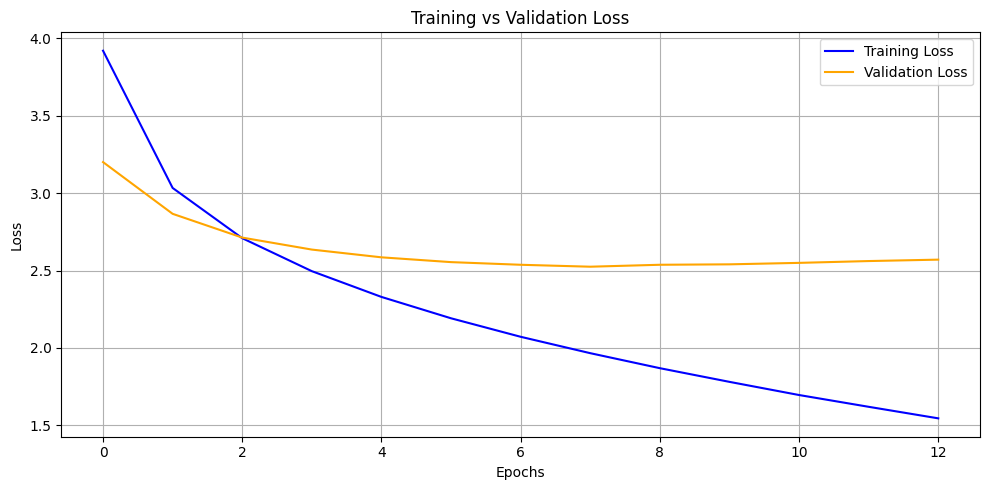

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## **7.2 Visualizing Attention Weights**

In [ ]:
def plot_attention(original_image_path, generated_words, attention_weights):
    raw_image = Image.open(original_image_path).convert('RGB')
    raw_image = raw_image.resize((224, 224), Image.LANCZOS)
    
    num_words = len(generated_words)
    cols = 4
    rows = (num_words // cols) + 1
    
    fig = plt.figure(figsize=(16, rows * 4))
    
    for i in range(num_words):
        ax = fig.add_subplot(rows, cols, i+1)
        
        word = generated_words[i]
        current_alpha = attention_weights[i]
        
        if current_alpha.max() > current_alpha.min():
            current_alpha = (current_alpha - current_alpha.min()) / (current_alpha.max() - current_alpha.min())
        
        ax.imshow(raw_image)

        alpha_img = Image.fromarray(current_alpha * 255)
        alpha_img = alpha_img.resize((224, 224), Image.BICUBIC)
        alpha_numpy = np.array(alpha_img)

        ax.imshow(alpha_numpy, cmap='gray', alpha=0.6, vmin=0, vmax=255)
        
        ax.set_title(f"'{word}'", fontsize=15, fontweight='bold', color='white', backgroundcolor='black')
        ax.axis('off')

        
    plt.tight_layout()
    plt.show()
    
    print("\nGenerated caption: " + " ".join(generated_words))

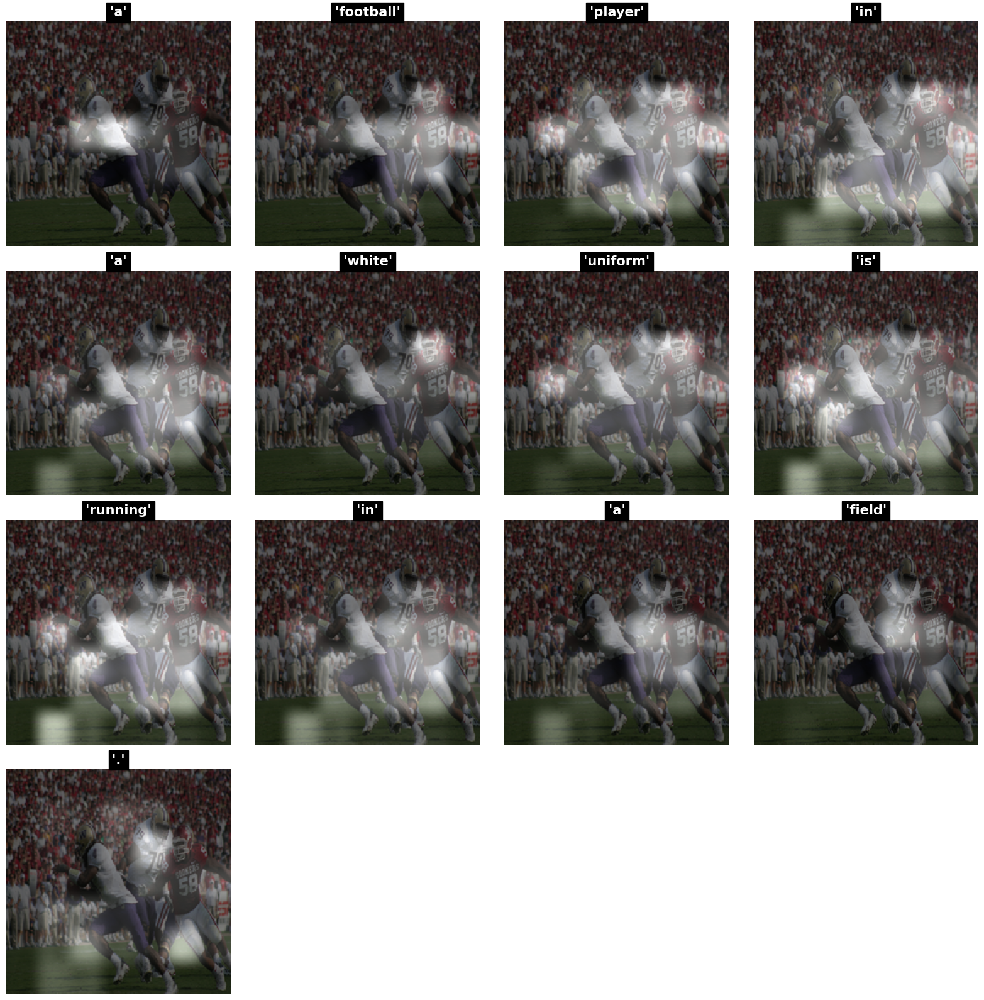


Generated caption: a football player in a white uniform is running in a field .


In [25]:
img_id = random.choice(test_dataset.df['image'].unique())
img_path = os.path.join("DATA/Images", img_id)

img_pil = Image.open(img_path).convert("RGB")
img_tensor = test_transforms(img_pil).unsqueeze(0)

words, alphas = model.generate(img_tensor, vocab, beam_width=1, device=device)
plot_attention(img_path, words, alphas)

## **7.3 Running Inference on the Image Captioning Model**

In [ ]:
from nltk.translate.bleu_score import corpus_bleu

def test_model(model, test_dataset, vocab, device, beam_width=3):
    references = []
    hypotheses = []

    unique_test_images = test_dataset.df['image'].unique()

    model.eval()

    for img_id in tqdm(unique_test_images):
        dataset_idx = test_dataset.df[test_dataset.df['image'] == img_id].index[0]
        img_tensor, _ = test_dataset[dataset_idx]
        img_tensor = img_tensor.unsqueeze(0).to(device)

        pred_caption, _ = model.generate(img_tensor, vocab, beam_width=beam_width, device=device)
        hypotheses.append(pred_caption)

        raw_captions = test_dataset.df[test_dataset.df['image'] == img_id]['caption'].tolist()

        img_refs = []
        for cap in raw_captions:
            tokens = vocab.tokenizer_eng(cap)
            img_refs.append(tokens)

        references.append(img_refs)


    print(f"Evaluation Results (Beam Width: {beam_width})")
    print("-"*30)

    weights = {
        "BLEU-1": (1.0, 0, 0, 0),
        "BLEU-2": (0.5, 0.5, 0, 0),
        "BLEU-3": (0.33, 0.33, 0.33, 0),
        "BLEU-4": (0.25, 0.25, 0.25, 0.25)
    }
    
    for name, weight in weights.items():
        score = corpus_bleu(references, hypotheses, weights=weight)
        print(f"{name}: {score * 100:.2f}")

    print("-"*30)

In [29]:
test_model(model, test_dataset, vocab, device, beam_width=3)

100%|██████████| 810/810 [00:36<00:00, 21.93it/s]


Evaluation Results (Beam Width: 3)
------------------------------
BLEU-1: 69.24
BLEU-2: 50.50
BLEU-3: 37.12
BLEU-4: 26.45
------------------------------


## **8. Loading an Existing Image Captioning Model**

In [44]:
from transformers import BlipProcessor, BlipForConditionalGeneration

model_id = "Salesforce/blip-image-captioning-base" 

processor = BlipProcessor.from_pretrained(model_id)
blip_model = BlipForConditionalGeneration.from_pretrained(model_id).to(device)

## **9. Evaluating the Existing Image Captioning Model**

In [ ]:
def generate_caption_blip(blip_model, image_path):
    raw_image = Image.open(image_path).convert('RGB')

    inputs = processor(raw_image, return_tensors="pt").to(device)

    out = blip_model.generate(
        **inputs, 
        max_new_tokens=20,
        num_beams=3,
        min_length=5
    )
    
    caption = processor.decode(out[0], skip_special_tokens=True)
    if not caption.endswith('.'):
        caption += " ."

    return caption


print("BLIP caption:", generate_caption_blip(blip_model, img_path))

BLIP caption: a large crowd of people watching a football game .


In [ ]:
def evaluate_pretrained_corrected(blip_model, test_dataset, vocab):    
    references = []
    hypotheses = []
    
    unique_ids = test_dataset.df['image'].unique()
        
    for img_id in tqdm(unique_ids): 
        img_path = os.path.join("DATA/Images", img_id)

        pred_text = generate_caption_blip(blip_model, img_path) 

        pred_tokens = vocab.tokenizer_eng(pred_text.lower())
        hypotheses.append(pred_tokens)
        
        raw_captions = test_dataset.df[test_dataset.df['image'] == img_id]['caption'].tolist()
        
        img_refs = [vocab.tokenizer_eng(c.lower()) for c in raw_captions]
        references.append(img_refs)

    weights = {
        "BLEU-1": (1.0, 0, 0, 0),
        "BLEU-2": (0.5, 0.5, 0, 0),
        "BLEU-3": (0.33, 0.33, 0.33, 0),
        "BLEU-4": (0.25, 0.25, 0.25, 0.25)
    }
    
    for name, weight in weights.items():
        score = corpus_bleu(references, hypotheses, weights=weight)
        print(f"{name}: {score * 100:.2f}")


evaluate_pretrained_corrected(blip_model, test_dataset, vocab)

100%|██████████| 810/810 [02:31<00:00,  5.33it/s]


BLEU-1: 67.85
BLEU-2: 49.81
BLEU-3: 36.96
BLEU-4: 27.02


## **10. Comparing the Two Models**

The evaluation results reveal a surprisingly competitive performance between my custom ResNet+LSTM model and the pre-trained BLIP model. My model achieved higher scores in BLEU-1 - BLEU-3, while BLIP edged out a victory in BLEU-4. 

This divergence is due to Specialization versus Generalization. My custom model acted as a specialist, by fine-tuning exclusively on Flickr8k, it memorized the specific vocabulary frequency and stylistic quirks of the annotators. In contrast, BLIP acted as a generalist. Trained on millions of web images, it utilized a broader vocabulary and synonyms that are semantically correct but penalized by the exact match nature of the BLEU metric.

Furthermore, the difference in Model Architecture played a key role. The custom model's LSTM decoder processes data sequentially, which is effective for short, simple sentences but struggles with long-range dependencies. BLIP's Transformer decoder utilizes self-attention to model global sentence structure, explaining its superior performance on BLEU-4, which measures longer phrase fluency and grammatical coherence.

**Proposed Improvements for my custom model:**

1. Architectural Upgrade: Replacing the LSTM with a Transformer Decoder would resolve the bottleneck of Recurrent Neural Networks, allowing the model to attend to all previously generated words simultaneously to improve sentence structure.
2. Encoder Upgrade: Replacing the ResNet-50 backbone with a modern architecture like Vision Transformer would allow the model to extract richer visual features.
3. Scheduled Sampling: Implementing Scheduled Sampling would reduce exposure bias and make the model more robust to errors during inference.

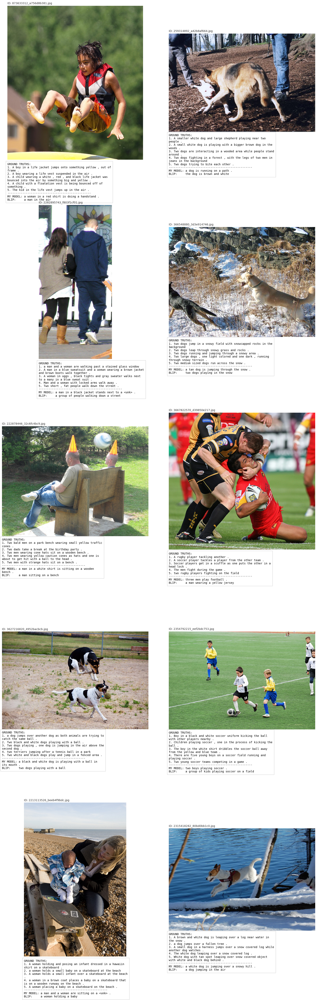

In [ ]:
import textwrap

def visualize_comparison_all_truths(my_model, blip_model, blip_processor, test_dataset, vocab, device, num_samples=6, beam_width=3):
    my_model.eval()
    blip_model.eval()
    
    unique_ids = test_dataset.df['image'].unique()
    num_samples = min(num_samples, len(unique_ids))
    sample_ids = np.random.choice(unique_ids, num_samples, replace=False)
    
    cols = 2
    rows = (num_samples + cols - 1) // cols
    
    _, axes = plt.subplots(rows, cols, figsize=(16, 10 * rows))
    axes = axes.flatten() if num_samples > 1 else [axes]
    
    for i, img_id in enumerate(sample_ids):
        ax = axes[i]
        img_path = os.path.join("DATA/Images", img_id)
        
        gt_captions = test_dataset.df[test_dataset.df['image'] == img_id]['caption'].tolist()

        dataset_idx = test_dataset.df[test_dataset.df['image'] == img_id].index[0]
        img_tensor_normalized, _ = test_dataset[dataset_idx]
        img_tensor_batch = img_tensor_normalized.unsqueeze(0).to(device)
        raw_image = Image.open(img_path).convert('RGB')

        my_caption_list, _ = my_model.generate(
            img_tensor_batch, vocab, beam_width=beam_width, device=device
        )
        my_caption = " ".join(my_caption_list)
        
        blip_inputs = blip_processor(raw_image, return_tensors="pt").to(device)
        blip_out = blip_model.generate(**blip_inputs, max_new_tokens=20, num_beams=beam_width, min_length=5)
        blip_caption = blip_processor.decode(blip_out[0], skip_special_tokens=True)

        ax.imshow(raw_image)
        ax.axis('off')
        
        text_block = "GROUND TRUTHS:\n"
        for idx, cap in enumerate(gt_captions):
            wrapped_truth = textwrap.fill(cap, width=60)
            text_block += f"{idx+1}. {wrapped_truth}\n"
            
        text_block += "-" * 50 + "\n"
        text_block += f"MY MODEL: {textwrap.fill(my_caption, width=50)}\n"
        text_block += f"BLIP:     {textwrap.fill(blip_caption, width=50)}"
        
        ax.set_title(f"ID: {img_id}", fontsize=10, loc='left')
        
        ax.text(
            0, -0.02, text_block, 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='square,pad=0.6', facecolor='white', edgecolor='lightgrey')
        )


    plt.tight_layout()
    plt.show()


visualize_comparison_all_truths(model, blip_model, processor, test_dataset, 
                                vocab, device, num_samples=10, beam_width=3)

After looking at some images and the captions I would say even though my model technically got a higher BLEU score, the BLIP model would produce subjectively more accurate descriptions of the images.